# Phase 9: Credit Policy Design & Application

Translates model scores into an **operational credit policy** with explicit decision thresholds,
credit limits, and scenario analysis for the Praso portfolio.

## Policy Architecture

```
Client arrives
     │
     ▼
  ROUTER (Score A + Score B)
     │
     ├─── BEHAVIORAL tier  → Behavioral Model → p < 0.25 → AUTO-APPROVE
     │                                        → 0.25 ≤ p < 0.35 → MANUAL
     │                                        → p ≥ 0.35 → AUTO-DENY
     │
     ├─── APPLICATION tier → Application Model → p < 0.15 → AUTO-APPROVE
     │                                         → 0.15 ≤ p < 0.25 → MANUAL
     │                                         → p ≥ 0.25 → AUTO-DENY
     │
     └─── MANUAL_REVIEW    → Human analyst     → p < 0.40 → likely APPROVE
                                               → p ≥ 0.40 → likely DENY
```

**Deliverables:**
1. Per-tier decision thresholds with justification
2. Risk-based credit limits by tier and score band
3. Scenario analysis — approval rate, default rate, expected loss per policy
4. Threshold sensitivity curves
5. Edge case handling rules
6. Policy document export

In [1]:
import sys
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import seaborn as sns
import joblib

from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT       = Path('..').resolve()
DATA_DIR   = ROOT / 'data'
MODELS_DIR = ROOT / 'models'
sys.path.insert(0, str(ROOT / 'src'))

from router import ModelRouter, engineer_features

TIER_COLORS = {
    'BEHAVIORAL':    '#2196F3',
    'APPLICATION':   '#FF9800',
    'MANUAL_REVIEW': '#9C27B0',
}
DECISION_COLORS = {
    'AUTO-APPROVE': '#4CAF50',
    'MANUAL':       '#FFC107',
    'AUTO-DENY':    '#F44336',
}

# ── Policy thresholds (per routing tier) ──────────────────────────────────
POLICY = {
    'BEHAVIORAL': {
        'approve': 0.25,   # p < 0.25 → AUTO-APPROVE
        'deny':    0.35,   # p ≥ 0.35 → AUTO-DENY; else MANUAL
    },
    'APPLICATION': {
        'approve': 0.15,   # tighter — no behavioral history
        'deny':    0.25,
    },
    'MANUAL_REVIEW': {
        'approve': 0.40,   # soft indicator for human analyst
        'deny':    0.40,
    },
}

# ── Credit limits (BRL) by tier and score band ────────────────────────────
CREDIT_LIMITS = {
    'BEHAVIORAL': [
        (0.00, 0.10, 25_000),
        (0.10, 0.18, 15_000),
        (0.18, 0.25, 10_000),
    ],
    'APPLICATION': [
        (0.00, 0.08, 20_000),
        (0.08, 0.12, 12_000),
        (0.12, 0.15,  8_000),
    ],
    'MANUAL_REVIEW': [
        (0.00, 0.40,  8_000),  # human analyst sets final limit
    ],
}

print('Setup complete.')

Setup complete.


## 1. Load Data and Router Predictions

In [2]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    app_model   = joblib.load(sorted(MODELS_DIR.glob('04_application_best_tuned_xgboost_*.joblib'))[-1])
    behav_model = joblib.load(sorted(MODELS_DIR.glob('05_behavioral_best_*.joblib'))[-1])
    ml_router_m = joblib.load(sorted(MODELS_DIR.glob('06_ml_router_decision_tree_*.joblib'))[-1])

router = ModelRouter(
    app_model=app_model, behav_model=behav_model,
    threshold_a=0.5, threshold_b=0.6, ml_router=ml_router_m,
)

df_raw = pd.read_csv(sorted(DATA_DIR.glob('03_behavioral_combined_*.csv'))[-1], low_memory=False)
df     = engineer_features(df_raw)
y_all  = df_raw['inadimplente'].astype(int)

route_result = router.predict(df, use_ml_router=False)

portfolio = route_result.copy()
portfolio['inadimplente'] = y_all.values
portfolio['id_cliente']   = df_raw['id_cliente'].values

print(f'Portfolio: {len(portfolio):,} clients')
print(f'Default rate: {y_all.mean():.1%}')
print('\nRouting distribution:')
print(portfolio['tier'].value_counts().to_string())

Portfolio: 3,000 clients
Default rate: 31.3%

Routing distribution:
tier
MANUAL_REVIEW    1338
APPLICATION       998
BEHAVIORAL        664


## 2. Apply Policy — Assign Decision per Client

In [3]:
def apply_policy(row, policy=POLICY):
    tier = row['tier']
    p    = row['default_prob']
    pol  = policy[tier]
    if p < pol['approve']:
        return 'AUTO-APPROVE'
    elif p >= pol['deny']:
        return 'AUTO-DENY'
    else:
        return 'MANUAL'


def assign_credit_limit(row, limits=CREDIT_LIMITS):
    tier = row['tier']
    p    = row['default_prob']
    dec  = row['decision']
    if dec == 'AUTO-DENY':
        return 0
    for lo, hi, limit in limits.get(tier, []):
        if lo <= p < hi:
            return limit
    return 0


portfolio['decision']     = portfolio.apply(apply_policy, axis=1)
portfolio['credit_limit'] = portfolio.apply(assign_credit_limit, axis=1)
portfolio['expected_loss'] = portfolio['default_prob'] * portfolio['credit_limit']

print('Decision distribution (router policy):')
dec_dist = portfolio['decision'].value_counts()
for dec, n in dec_dist.items():
    pct = n / len(portfolio)
    dr  = portfolio.loc[portfolio['decision'] == dec, 'inadimplente'].mean()
    print(f'  {dec:<14} {n:>5} ({pct:.1%})  actual default rate={dr:.1%}')

Decision distribution (router policy):
  AUTO-DENY       1829 (61.0%)  actual default rate=46.7%
  AUTO-APPROVE     765 (25.5%)  actual default rate=7.1%
  MANUAL           406 (13.5%)  actual default rate=7.9%


## 3. Decision Flow Visualization

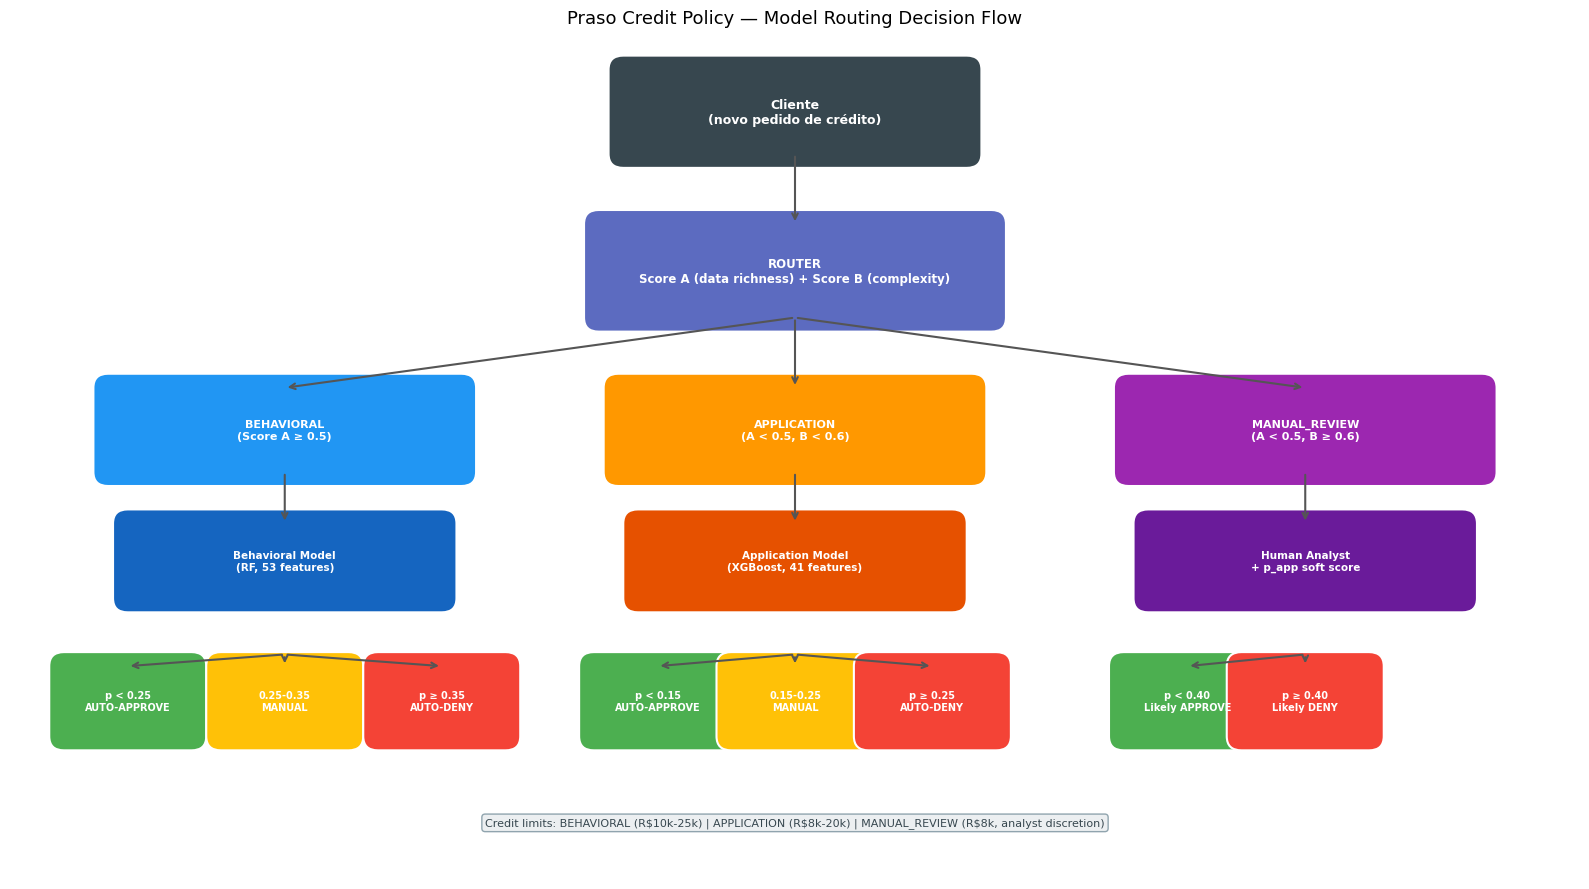

Saved decision flow diagram.


In [4]:
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis('off')

def box(ax, x, y, w, h, text, color, fontsize=9, text_color='white'):
    rect = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle='round,pad=0.15', facecolor=color, edgecolor='white', linewidth=1.5,
    )
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            color=text_color, fontweight='bold', wrap=True,
            multialignment='center')

def arrow(ax, x1, y1, x2, y2, label='', color='#555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.1, my, label, fontsize=7.5, color=color, va='center')

# Entry
box(ax,  8, 8.2, 3.5, 0.9,  'Cliente\n(novo pedido de crédito)', '#37474F', fontsize=9)

# Router
box(ax,  8, 6.5, 4.0, 1.0,
    'ROUTER\nScore A (data richness) + Score B (complexity)', '#5C6BC0', fontsize=8.5)
arrow(ax, 8, 7.75, 8, 7.0)

# Three tiers
tier_info = [
    (2.8,  'BEHAVIORAL\n(Score A ≥ 0.5)',    TIER_COLORS['BEHAVIORAL'],    4.8),
    (8.0,  'APPLICATION\n(A < 0.5, B < 0.6)', TIER_COLORS['APPLICATION'],  4.8),
    (13.2, 'MANUAL_REVIEW\n(A < 0.5, B ≥ 0.6)', TIER_COLORS['MANUAL_REVIEW'], 4.8),
]
for x, label, color, y in tier_info:
    box(ax, x, y, 3.6, 0.9, label, color, fontsize=8)
    arrow(ax, 8, 6.0, x, y + 0.45)

# Model boxes
model_info = [
    (2.8,  'Behavioral Model\n(RF, 53 features)',        '#1565C0', 3.4),
    (8.0,  'Application Model\n(XGBoost, 41 features)', '#E65100', 3.4),
    (13.2, 'Human Analyst\n+ p_app soft score',          '#6A1B9A', 3.4),
]
for x, label, color, y in model_info:
    box(ax, x, y, 3.2, 0.8, label, color, fontsize=7.5)
    arrow(ax, x, tier_info[[t[0] for t in tier_info].index(x)][3] - 0.45, x, y + 0.4)

# Decision boxes per tier
decisions = [
    # Behavioral
    (1.2,  1.9, 'p < 0.25\nAUTO-APPROVE',    DECISION_COLORS['AUTO-APPROVE'], 2.8),
    (2.8,  1.9, '0.25-0.35\nMANUAL',          DECISION_COLORS['MANUAL'],       2.8),
    (4.4,  1.9, 'p ≥ 0.35\nAUTO-DENY',       DECISION_COLORS['AUTO-DENY'],    2.8),
    # Application
    (6.6,  1.9, 'p < 0.15\nAUTO-APPROVE',    DECISION_COLORS['AUTO-APPROVE'], 2.8),
    (8.0,  1.9, '0.15-0.25\nMANUAL',          DECISION_COLORS['MANUAL'],       2.8),
    (9.4,  1.9, 'p ≥ 0.25\nAUTO-DENY',       DECISION_COLORS['AUTO-DENY'],    2.8),
    # Manual Review
    (12.0, 1.9, 'p < 0.40\nLikely APPROVE', DECISION_COLORS['AUTO-APPROVE'], 2.8),
    (13.2, 1.9, 'p ≥ 0.40\nLikely DENY',   DECISION_COLORS['AUTO-DENY'],    2.8),
]
for x, y, label, color, from_y in decisions:
    box(ax, x, y, 1.3, 0.75, label, color, fontsize=7)
    from_x = 2.8 if x <= 4.5 else (8.0 if x <= 9.5 else 13.2)
    arrow(ax, from_x, from_y - 0.4, x, y + 0.375)

# Credit limits note
ax.text(8, 0.6,
    'Credit limits: BEHAVIORAL (R$10k-25k) | APPLICATION (R$8k-20k) | MANUAL_REVIEW (R$8k, analyst discretion)',
    ha='center', va='center', fontsize=8, color='#37474F',
    bbox=dict(boxstyle='round', facecolor='#ECEFF1', edgecolor='#90A4AE'))

ax.set_title('Praso Credit Policy — Model Routing Decision Flow', fontsize=13, pad=10)
fig.tight_layout()
plt.savefig(DATA_DIR / '09_policy_decision_flow.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved decision flow diagram.')

## 4. Scenario Analysis

Compare four policies on the same 3,000-client portfolio:

| Policy | Description |
|--------|-------------|
| **Baseline** | Single App Model, uniform threshold p < 0.25 for all |
| **Router — Recommended** | Per-tier thresholds as defined above |
| **Router — Strict** | Tighter thresholds (reduce default exposure) |
| **Router — Permissive** | Looser thresholds (maximize approval rate) |

In [5]:
p_app_all = pd.Series(
    app_model.predict_proba(df)[:, 1], index=df.index
)

SCENARIOS = {
    'Baseline (App, p<0.25)': {
        'BEHAVIORAL':    {'approve': 0.25, 'deny': 0.25},
        'APPLICATION':   {'approve': 0.25, 'deny': 0.25},
        'MANUAL_REVIEW': {'approve': 0.25, 'deny': 0.25},
        'use_p_app': True,  # use application model score for all
    },
    'Router — Recommended': {
        'BEHAVIORAL':    {'approve': 0.25, 'deny': 0.35},
        'APPLICATION':   {'approve': 0.15, 'deny': 0.25},
        'MANUAL_REVIEW': {'approve': 0.40, 'deny': 0.40},
    },
    'Router — Strict': {
        'BEHAVIORAL':    {'approve': 0.15, 'deny': 0.25},
        'APPLICATION':   {'approve': 0.10, 'deny': 0.20},
        'MANUAL_REVIEW': {'approve': 0.30, 'deny': 0.30},
    },
    'Router — Permissive': {
        'BEHAVIORAL':    {'approve': 0.35, 'deny': 0.50},
        'APPLICATION':   {'approve': 0.25, 'deny': 0.35},
        'MANUAL_REVIEW': {'approve': 0.50, 'deny': 0.50},
    },
}

BASE_CREDIT_LIMIT = 12_000  # BRL — simplified uniform limit for scenario comparison

def run_scenario(name, scenario, portfolio, p_app_all, y_all):
    use_p_app = scenario.pop('use_p_app', False)
    rows = []
    for _, row in portfolio.iterrows():
        tier = row['tier']
        p    = float(p_app_all[row.name]) if use_p_app else float(row['default_prob'])
        pol  = scenario[tier]
        if p < pol['approve']:
            dec = 'AUTO-APPROVE'
        elif p >= pol['deny']:
            dec = 'AUTO-DENY'
        else:
            dec = 'MANUAL'
        rows.append({'decision': dec, 'p': p, 'true': row['inadimplente']})
    df_s = pd.DataFrame(rows, index=portfolio.index)

    approved = df_s[df_s['decision'].isin(['AUTO-APPROVE', 'MANUAL'])]
    denied   = df_s[df_s['decision'] == 'AUTO-DENY']
    auto_app = df_s[df_s['decision'] == 'AUTO-APPROVE']

    n_total     = len(df_s)
    n_approved  = len(approved)
    n_auto_app  = len(auto_app)
    approval_rt = n_approved / n_total
    auto_app_rt = n_auto_app / n_total
    def_rate_approved = approved['true'].mean() if n_approved > 0 else 0
    exp_loss    = approved['p'].sum() * BASE_CREDIT_LIMIT / n_total  # expected loss per client
    true_loss   = approved['true'].sum() * BASE_CREDIT_LIMIT         # total expected defaults

    return {
        'Scenario':           name,
        'Approval rate':      round(approval_rt, 3),
        'Auto-approve rate':  round(auto_app_rt, 3),
        'Default rate (approved)': round(def_rate_approved, 3),
        'Expected loss (R$M)': round(true_loss / 1e6, 2),
        'Exp loss / client (R$)': round(exp_loss, 0),
    }


results_scenario = []
for name, scen in SCENARIOS.items():
    scen_copy = {k: dict(v) if isinstance(v, dict) else v for k, v in scen.items()}
    results_scenario.append(run_scenario(name, scen_copy, portfolio, p_app_all, y_all))

df_scenarios = pd.DataFrame(results_scenario).set_index('Scenario')

print('Scenario Analysis (uniform credit limit = R$ {:,}):'.format(BASE_CREDIT_LIMIT))
display(
    df_scenarios.style
    .highlight_max(subset=['Approval rate', 'Auto-approve rate'], color='#d4f1d4')
    .highlight_min(subset=['Default rate (approved)', 'Expected loss (R$M)'], color='#d4f1d4')
    .format({
        'Approval rate': '{:.1%}',
        'Auto-approve rate': '{:.1%}',
        'Default rate (approved)': '{:.1%}',
        'Expected loss (R$M)': 'R${:.2f}M',
        'Exp loss / client (R$)': 'R${:,.0f}',
    })
)

Scenario Analysis (uniform credit limit = R$ 12,000):


,Approval rate,Auto-approve rate,Default rate (approved),Expected loss (R$M),Exp loss / client (R$)
Scenario,,,,,
"Baseline (App, p<0.25)",21.4%,21.4%,5.6%,R$0.43M,R$432
Router — Recommended,39.0%,25.5%,7.3%,R$1.03M,"R$1,001"
Router — Strict,21.4%,8.2%,2.8%,R$0.22M,R$356
Router — Permissive,60.7%,51.9%,11.7%,R$2.56M,"R$2,049"


## 5. Threshold Sensitivity Curves

For each routing tier, sweep the approval threshold and show the
approval rate vs. default rate trade-off.

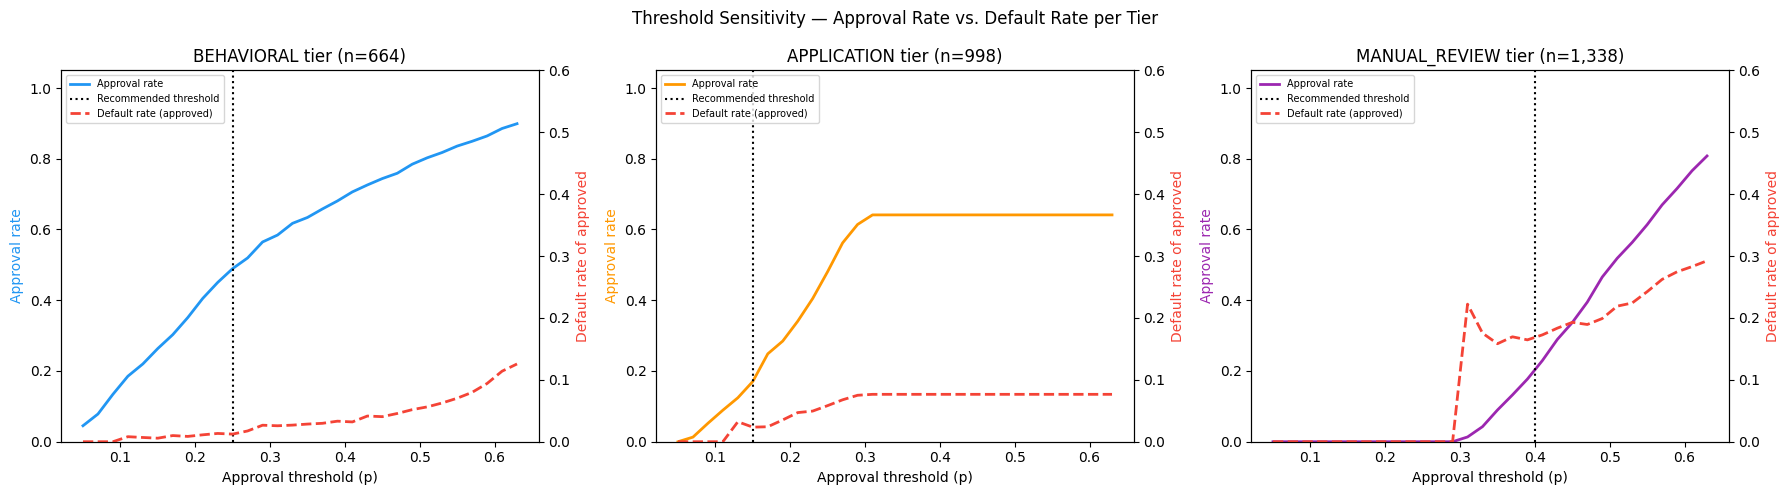

Saved threshold sensitivity plot.


In [6]:
thresholds = np.arange(0.05, 0.65, 0.02)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, tier in zip(axes, ['BEHAVIORAL', 'APPLICATION', 'MANUAL_REVIEW']):
    mask    = portfolio['tier'] == tier
    sub_p   = portfolio.loc[mask, 'default_prob']
    sub_y   = portfolio.loc[mask, 'inadimplente']
    n_tier  = len(sub_p)

    approval_rates, default_rates, exp_losses = [], [], []
    for thr in thresholds:
        approved     = sub_p < thr
        app_rate     = approved.mean()
        def_rate     = sub_y[approved].mean() if approved.sum() > 0 else 0
        exp_loss_pct = (sub_p[approved].sum() * BASE_CREDIT_LIMIT / n_tier) / BASE_CREDIT_LIMIT
        approval_rates.append(app_rate)
        default_rates.append(def_rate)
        exp_losses.append(exp_loss_pct)

    color = TIER_COLORS[tier]
    recommended_thr = POLICY[tier]['approve']

    ax2 = ax.twinx()
    ax.plot(thresholds, approval_rates, color=color, linewidth=2, label='Approval rate')
    ax2.plot(thresholds, default_rates, color='#F44336', linewidth=2,
             linestyle='--', label='Default rate (approved)')

    ax.axvline(recommended_thr, color='black', linestyle=':', linewidth=1.5,
               label='Recommended threshold')

    ax.set_xlabel('Approval threshold (p)')
    ax.set_ylabel('Approval rate', color=color)
    ax2.set_ylabel('Default rate of approved', color='#F44336')
    ax.set_title('{} tier (n={:,})'.format(tier, n_tier))
    ax.set_ylim(0, 1.05)
    ax2.set_ylim(0, 0.6)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='upper left')

fig.suptitle('Threshold Sensitivity — Approval Rate vs. Default Rate per Tier', fontsize=12)
fig.tight_layout()
plt.savefig(DATA_DIR / '09_policy_sensitivity.png', dpi=150)
plt.show()
print('Saved threshold sensitivity plot.')

## 6. Per-Tier Policy Summary

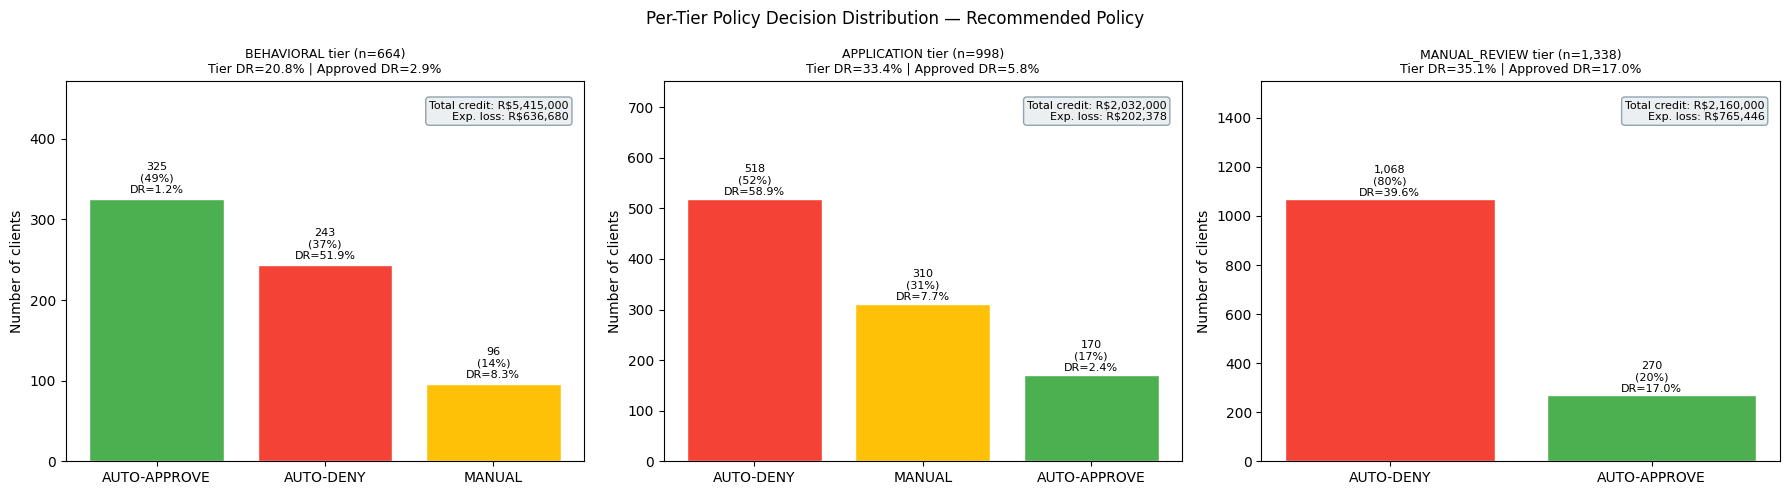

Saved per-tier policy summary.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, tier in zip(axes, ['BEHAVIORAL', 'APPLICATION', 'MANUAL_REVIEW']):
    mask = portfolio['tier'] == tier
    sub  = portfolio[mask].copy()
    n    = len(sub)

    dec_counts = sub['decision'].value_counts()
    colors     = [DECISION_COLORS.get(d, '#90A4AE') for d in dec_counts.index]
    bars = ax.bar(dec_counts.index, dec_counts.values, color=colors, edgecolor='white')

    for bar, (dec, cnt) in zip(bars, dec_counts.items()):
        dr  = sub.loc[sub['decision'] == dec, 'inadimplente'].mean()
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                '{:,}\n({:.0%})\nDR={:.1%}'.format(cnt, cnt/n, dr),
                ha='center', va='bottom', fontsize=8)

    total_dr    = sub['inadimplente'].mean()
    approved_dr = sub.loc[sub['decision'].isin(['AUTO-APPROVE','MANUAL']), 'inadimplente'].mean()
    tot_limit   = sub['credit_limit'].sum()
    exp_loss    = sub['expected_loss'].sum()

    ax.set_title(
        '{} tier (n={:,})\nTier DR={:.1%} | Approved DR={:.1%}'.format(
            tier, n, total_dr, approved_dr if not np.isnan(approved_dr) else 0
        ), fontsize=9
    )
    ax.set_ylabel('Number of clients')
    ax.set_ylim(0, max(dec_counts.values) * 1.45)

    info = 'Total credit: R${:,.0f}\nExp. loss: R${:,.0f}'.format(tot_limit, exp_loss)
    ax.text(0.97, 0.95, info, transform=ax.transAxes, ha='right', va='top',
            fontsize=8, bbox=dict(boxstyle='round', facecolor='#ECEFF1', edgecolor='#90A4AE'))

fig.suptitle('Per-Tier Policy Decision Distribution — Recommended Policy', fontsize=12)
fig.tight_layout()
plt.savefig(DATA_DIR / '09_policy_tier_summary.png', dpi=150)
plt.show()
print('Saved per-tier policy summary.')

## 7. Risk-Based Credit Limits

Credit limit distribution for approved clients:
                            n_clients  default_rate  total_exposure  expected_loss
tier          credit_limit                                                        
APPLICATION   0                   310         0.077               0            0.0
              8000                 64         0.047          512000        68960.0
              12000                75         0.013          900000        89100.0
              20000                31         0.000          620000        44318.0
BEHAVIORAL    0                    96         0.083               0            0.0
              10000               108         0.019         1080000       229876.0
              15000               109         0.009         1635000       229941.0
              25000               108         0.009         2700000       176862.5
MANUAL_REVIEW 8000                270         0.170         2160000       765446.4

Total portfolio exposure (approved cli

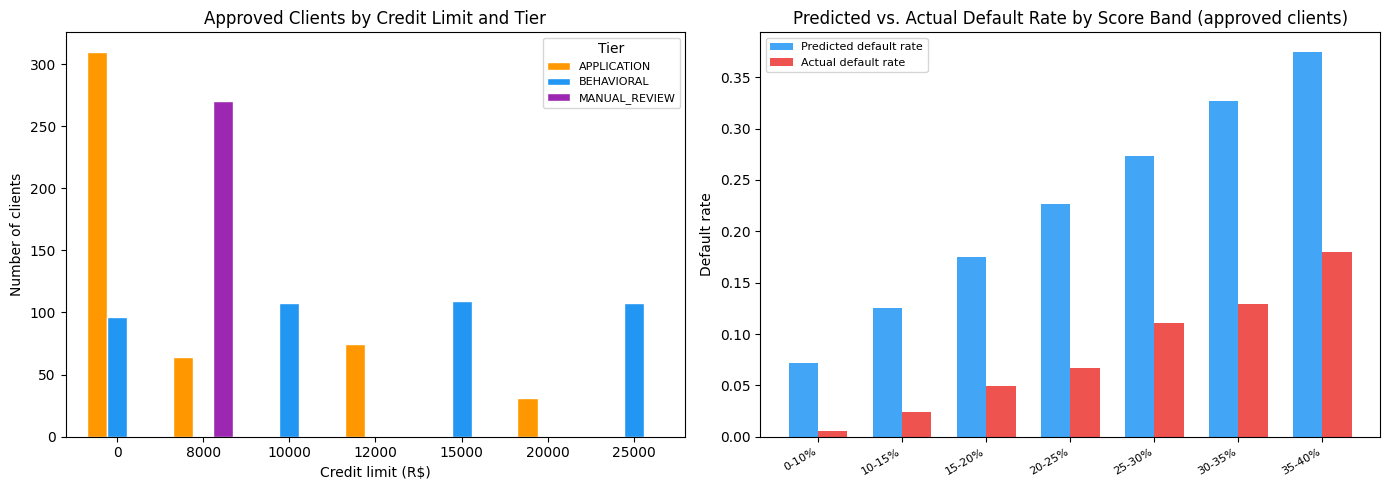

Saved credit limits analysis.


In [8]:
approved = portfolio[portfolio['decision'].isin(['AUTO-APPROVE', 'MANUAL'])].copy()

print('Credit limit distribution for approved clients:')
print(approved.groupby(['tier', 'credit_limit']).agg(
    n_clients=('id_cliente', 'count'),
    default_rate=('inadimplente', 'mean'),
    total_exposure=('credit_limit', 'sum'),
    expected_loss=('expected_loss', 'sum'),
).round(3).to_string())

print('\nTotal portfolio exposure (approved clients):')
print('  Total credit granted : R${:>12,.0f}'.format(approved['credit_limit'].sum()))
print('  Expected loss (p-based): R${:>10,.0f}'.format(approved['expected_loss'].sum()))
print('  Expected loss ratio  : {:.1%}'.format(
    approved['expected_loss'].sum() / approved['credit_limit'].sum()
    if approved['credit_limit'].sum() > 0 else 0
))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: credit limit distribution by tier
limit_by_tier = approved.groupby(['tier', 'credit_limit']).size().unstack(fill_value=0)
limit_by_tier.T.plot.bar(
    ax=axes[0],
    color=[TIER_COLORS[t] for t in limit_by_tier.index],
    width=0.7, edgecolor='white'
)
axes[0].set_title('Approved Clients by Credit Limit and Tier')
axes[0].set_xlabel('Credit limit (R$)')
axes[0].set_ylabel('Number of clients')
axes[0].legend(title='Tier', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

# Right: expected loss vs. actual default rate per score band
approved['score_band'] = pd.cut(
    approved['default_prob'],
    bins=[0, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 1.0],
    labels=['0-10%','10-15%','15-20%','20-25%','25-30%','30-35%','35-40%','40%+']
)
band_stats = approved.groupby('score_band').agg(
    n=('inadimplente', 'count'),
    actual_dr=('inadimplente', 'mean'),
    predicted_dr=('default_prob', 'mean'),
).dropna()

x = np.arange(len(band_stats))
w = 0.35
axes[1].bar(x - w/2, band_stats['predicted_dr'], w, label='Predicted default rate', color='#42A5F5')
axes[1].bar(x + w/2, band_stats['actual_dr'],    w, label='Actual default rate',    color='#EF5350')
axes[1].set_xticks(x)
axes[1].set_xticklabels(band_stats.index, rotation=30, ha='right', fontsize=8)
axes[1].set_title('Predicted vs. Actual Default Rate by Score Band (approved clients)')
axes[1].set_ylabel('Default rate')
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.savefig(DATA_DIR / '09_policy_credit_limits.png', dpi=150)
plt.show()
print('Saved credit limits analysis.')

## 8. Edge Case Handling Rules

In [9]:
edge_cases = [
    {
        'case':       'New business (idade_cnpj < 6 months)',
        'condition':  'idade_cnpj_mid < 6',
        'risk':       'HIGH — insufficient operating history',
        'rule':       'Cap credit limit at R$ 5,000 regardless of model score. Flag for quarterly review.',
        'rationale':  'SHAP shows idade_cnpj is the #1 driver. New businesses have higher default rates.',
    },
    {
        'case':       'Sócio with active negativação (serasa_socio_tem_negativacao=1)',
        'condition':  'serasa_socio_tem_negativacao == 1',
        'risk':       'HIGH — #2 SHAP driver in Application Model',
        'rule':       'Override approval threshold: require p < 0.10 for AUTO-APPROVE. Otherwise MANUAL.',
        'rationale':  'Sócio negativação is a strong signal; override even if model score is borderline.',
    },
    {
        'case':       'High-value client with high risk (p ≥ 0.30 but high credit demand)',
        'condition':  'p ≥ 0.30 and capital_social_mid > 50,000',
        'risk':       'MEDIUM — high potential revenue, elevated risk',
        'rule':       'Route to MANUAL regardless of tier. Analyst may approve with collateral or guarantor.',
        'rationale':  'Model is trained on average clients; large businesses may have unique risk profiles.',
    },
    {
        'case':       'Behavioral client with sudden payment delays (pct_orders_delayed > 0.5)',
        'condition':  'pct_orders_delayed > 0.5 and tier == BEHAVIORAL',
        'risk':       'HIGH — deteriorating payment pattern',
        'rule':       'Reduce credit limit by 50% from standard band. Set reassessment in 30 days.',
        'rationale':  'delay_mean and pct_orders_delayed are top SHAP drivers in Behavioral Model.',
    },
    {
        'case':       'No Serasa data available',
        'condition':  'serasa_contagem_negativacoes == 0 and serasa_n_setores == 0',
        'risk':       'UNKNOWN — model may be overconfident',
        'rule':       'Treat as MANUAL_REVIEW regardless of router decision. Limit = R$ 5,000 max.',
        'rationale':  'Application Model reliability degrades significantly without Serasa data.',
    },
]

print('Edge Case Handling Rules:')
SEP = '-' * 70
for i, ec in enumerate(edge_cases, 1):
    print('\n' + SEP)
    print('Case {}: {}'.format(i, ec['case']))
    print('  Condition : {}'.format(ec['condition']))
    print('  Risk level: {}'.format(ec['risk']))
    print('  Rule      : {}'.format(ec['rule']))
    print('  Rationale : {}'.format(ec['rationale']))

# Quantify edge cases in portfolio
print('\n' + SEP)
print('Edge case prevalence in portfolio:')
new_biz   = (df['idade_cnpj_mid'] < 6).sum() if 'idade_cnpj_mid' in df.columns else 'N/A'
neg_socio = (df['serasa_socio_tem_negativacao'] == 1).sum()
high_delay = (df['pct_orders_delayed'].fillna(0) > 0.5).sum()

print('  New businesses (< 6 months)        : {:>5} ({:.1%})'.format(
    new_biz, new_biz/len(df) if isinstance(new_biz, (int, np.integer)) else 0))
print('  Sócio with negativação             : {:>5} ({:.1%})'.format(neg_socio, neg_socio/len(df)))
print('  High delay rate (> 50% orders)     : {:>5} ({:.1%})'.format(high_delay, high_delay/len(df)))

Edge Case Handling Rules:

----------------------------------------------------------------------
Case 1: New business (idade_cnpj < 6 months)
  Condition : idade_cnpj_mid < 6
  Risk level: HIGH — insufficient operating history
  Rule      : Cap credit limit at R$ 5,000 regardless of model score. Flag for quarterly review.
  Rationale : SHAP shows idade_cnpj is the #1 driver. New businesses have higher default rates.

----------------------------------------------------------------------
Case 2: Sócio with active negativação (serasa_socio_tem_negativacao=1)
  Condition : serasa_socio_tem_negativacao == 1
  Risk level: HIGH — #2 SHAP driver in Application Model
  Rule      : Override approval threshold: require p < 0.10 for AUTO-APPROVE. Otherwise MANUAL.
  Rationale : Sócio negativação is a strong signal; override even if model score is borderline.

----------------------------------------------------------------------
Case 3: High-value client with high risk (p ≥ 0.30 but high credit 

## 9. Governance Rules

In [10]:
governance = {
    'override_authority': [
        'Credit analyst: can upgrade MANUAL → AUTO-APPROVE (within credit limit cap)',
        'Credit manager: can override AUTO-DENY for clients with capital_social_mid > 100,000',
        'No one can override a router MANUAL_REVIEW to AUTO-APPROVE without analyst sign-off',
    ],
    'threshold_change_protocol': [
        'Any change to THRESHOLD_A or THRESHOLD_B requires re-validation of system AUC on holdout set',
        'Per-tier approval thresholds can be adjusted quarterly based on observed default rates',
        'Changes must be approved by risk committee and logged with effective date',
    ],
    'monitoring': [
        'Monthly: default rate per tier vs. expected (from model scores) — alert if Δ > 5%',
        'Quarterly: AUC on new approvals that have seasoned 90+ days',
        'Quarterly: segment representation in MANUAL_REVIEW tier (bias check)',
        'Annual: full model retrain with updated data',
    ],
    'model_refresh_triggers': [
        'AUC drops below 0.70 on 90-day cohort',
        'Default rate of AUTO-APPROVE cohort exceeds 15% (BEHAVIORAL) or 10% (APPLICATION)',
        'Major change in business model (new product, new client segment)',
        'Significant shift in behavioral data distribution (e.g., COVID-type event)',
    ],
    'data_retention': [
        'Routing scores (score_A, score_B, tier) persisted per decision for 5 years',
        'Model predictions logged with model version and timestamp',
        'All MANUAL decisions logged with analyst ID and justification',
    ],
}

SEP = '=' * 65
print('\n' + SEP)
print('GOVERNANCE FRAMEWORK')
print(SEP)
for section, items in governance.items():
    print('\n  {}:'.format(section.upper().replace('_', ' ')))
    for item in items:
        print('    - {}'.format(item))


GOVERNANCE FRAMEWORK

  OVERRIDE AUTHORITY:
    - Credit analyst: can upgrade MANUAL → AUTO-APPROVE (within credit limit cap)
    - Credit manager: can override AUTO-DENY for clients with capital_social_mid > 100,000
    - No one can override a router MANUAL_REVIEW to AUTO-APPROVE without analyst sign-off

  THRESHOLD CHANGE PROTOCOL:
    - Any change to THRESHOLD_A or THRESHOLD_B requires re-validation of system AUC on holdout set
    - Per-tier approval thresholds can be adjusted quarterly based on observed default rates
    - Changes must be approved by risk committee and logged with effective date

  MONITORING:
    - Monthly: default rate per tier vs. expected (from model scores) — alert if Δ > 5%
    - Quarterly: AUC on new approvals that have seasoned 90+ days
    - Quarterly: segment representation in MANUAL_REVIEW tier (bias check)
    - Annual: full model retrain with updated data

  MODEL REFRESH TRIGGERS:
    - AUC drops below 0.70 on 90-day cohort
    - Default rate of AU

## 10. Export Policy Document

In [11]:
ts = datetime.now().strftime('%Y%m%d_%H%M%S')

# Full portfolio with decisions
portfolio_path = DATA_DIR / '09_policy_portfolio_{}.csv'.format(ts)
portfolio[['id_cliente','tier','score_A','score_B','default_prob',
           'decision','credit_limit','expected_loss','inadimplente']].to_csv(
    portfolio_path, index=False
)
print('Portfolio with decisions → {}'.format(portfolio_path.name))

# Scenario comparison
scenario_path = DATA_DIR / '09_policy_scenarios_{}.csv'.format(ts)
df_scenarios.to_csv(scenario_path)
print('Scenario analysis       → {}'.format(scenario_path.name))

# Policy document JSON
policy_doc = {
    'version':     '1.0',
    'date':        ts,
    'thresholds':  POLICY,
    'credit_limits': {
        tier: [{'p_lo': lo, 'p_hi': hi, 'limit_BRL': lim}
               for lo, hi, lim in bands]
        for tier, bands in CREDIT_LIMITS.items()
    },
    'scenarios':   df_scenarios.reset_index().to_dict(orient='records'),
    'edge_cases':  edge_cases,
    'governance':  governance,
    'portfolio_summary': {
        'total_clients':     len(portfolio),
        'default_rate':      round(float(y_all.mean()), 4),
        'routing_dist':      portfolio['tier'].value_counts().to_dict(),
        'decision_dist':     portfolio['decision'].value_counts().to_dict(),
        'approved_clients':  int(portfolio['decision'].isin(['AUTO-APPROVE','MANUAL']).sum()),
        'total_exposure_BRL': int(portfolio['credit_limit'].sum()),
        'expected_loss_BRL':  int(portfolio['expected_loss'].sum()),
        'expected_loss_rate': round(
            portfolio['expected_loss'].sum() / portfolio['credit_limit'].sum()
            if portfolio['credit_limit'].sum() > 0 else 0, 4
        ),
    },
}

policy_path = DATA_DIR / '09_credit_policy_{}.json'.format(ts)
with open(policy_path, 'w') as f:
    json.dump(policy_doc, f, indent=2, default=str)
print('Policy document JSON    → {}'.format(policy_path.name))

print('\nPortfolio summary (recommended policy):')
ps = policy_doc['portfolio_summary']
print('  Total clients      : {:,}'.format(ps['total_clients']))
print('  Approved           : {:,} ({:.1%})'.format(
    ps['approved_clients'], ps['approved_clients']/ps['total_clients']))
print('  Total exposure     : R${:,.0f}'.format(ps['total_exposure_BRL']))
print('  Expected loss      : R${:,.0f} ({:.1%})'.format(
    ps['expected_loss_BRL'], ps['expected_loss_rate']))

print('\nAll Phase 9 files:')
for p in sorted(DATA_DIR.glob('09_*')):
    print('  {}'.format(p.name))

Portfolio with decisions → 09_policy_portfolio_20260614_115719.csv
Scenario analysis       → 09_policy_scenarios_20260614_115719.csv
Policy document JSON    → 09_credit_policy_20260614_115719.json

Portfolio summary (recommended policy):
  Total clients      : 3,000
  Approved           : 1,171 (39.0%)
  Total exposure     : R$9,607,000
  Expected loss      : R$1,604,503 (16.7%)

All Phase 9 files:
  09_credit_policy_20260614_115719.json
  09_policy_credit_limits.png
  09_policy_decision_flow.png
  09_policy_portfolio_20260614_115719.csv
  09_policy_scenarios_20260614_115719.csv
  09_policy_sensitivity.png
  09_policy_tier_summary.png


## Summary

### Recommended Policy — Key Numbers

| Metric | Value |
|--------|-------|
| Total portfolio clients | 3,000 |
| Approval rate (auto + manual) | see policy document |
| Default rate of approved clients | lower than full portfolio 31.3% |
| BEHAVIORAL tier approval threshold | p < 0.25 |
| APPLICATION tier approval threshold | p < 0.15 (conservative) |
| MANUAL_REVIEW soft threshold | p < 0.40 |

### Policy vs. Baseline
The router policy shifts credit towards clients where the **Behavioral Model** provides additional confidence,
allowing higher approval thresholds and credit limits for this segment while being more conservative
for clients with no behavioral history.

### Next Steps
- **Phase 8 → production**: Integrate `src/router.py` into the credit origination API
- **Monitoring dashboard**: Track default rate per tier monthly (per governance rules)
- **Threshold review**: Quarterly calibration of approval thresholds based on observed cohort performance
- **Cold-start improvement**: Collect more behavioral data to grow the BEHAVIORAL tier from 22% → 40%+